<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Tianguis-Ciudad-de-Mexico-2022-Python/blob/main/Tianguis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cargar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer dataset
tianguis = pd.read_csv('tianguis_cdmx.csv')
tianguis

,alcaldia,colonia,ubicacion,giro,dia,horario,latitud,longitud
0,ALVARO OBREGON,PILOTO (ADOLFO LOPEZ MATEOS) (AMPL),ADOLFO DE LA HUERTA ENTRE RUIZ CORTINEZ Y BENI...,NaN,LUNES,8:00 A 17:00 HORAS,19.375612,-99.221648
1,ALVARO OBREGON,GOLONDRINAS 1RA SECCION,AV. CHICAGO ENTRE URANO Y JUPITER,NaN,LUNES,8:00 A 17:00 HORAS,19.381123,-99.209121
2,ALVARO OBREGON,JOSE MARIA PINO SUAREZ,PONIENTE 85 Y AV. OBSERVATORIO,NaN,LUNES,8:00 A 17:00 HORAS,19.398888,-99.197936
3,ALVARO OBREGON,TLACUITLAPA,CALLE LAS TORRES Y ANTONIO MACHADO,NaN,LUNES,8:00 A 17:00 HORAS,19.355768,-99.240129
4,ALVARO OBREGON,MARIA G DE GARCIA RUIZ,AV. MEXICANOS ENT. BRASILEÃ‘OS Y URUGUAYOS,NaN,LUNES,8:00 A 17:00 HORAS,19.385972,-99.212968
...,...,...,...,...,...,...,...,...
1362,GUSTAVO A. MADERO,UNIDAD HABITACIONAL VILLA DE ARAGON,VILLA CACAMA ENTRE AV. CENTRAL Y HANK GONZALEZ...,NaN,DOMINGO,07:00 A 17:00 HORAS,19.463950,-99.056909
1363,MILPA ALTA,SAN PABLO OZTOTEPEC,CALLE MORELOS ESQUINA CON ZAPATA Y CALLE ROJO ...,ABASTO,VIERNES,8:00 A 17:00 HORAS,19.186960,-99.072973
1364,TLALPAN,COL. CHIMALCOYOTL,HERMANOS PINZON Y CRISTOBAL COLÓN,NaN,MIÉRCOLES,08:00 A 19:00 HORAS,19.273726,-99.167265
1365,COYOACÁN,CARMEN SERDÁN,BOULEVARD CARMEN SERDÁN ENTRE MAGDALENA COBOS ...,0,MIÉRCOLES,8:00 A 19:00 HORAS,4.420572,-99.102604


In [3]:
# Información del dataset
tianguis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   alcaldia   1367 non-null   object 
 1   colonia    1367 non-null   object 
 2   ubicacion  1367 non-null   object 
 3   giro       314 non-null    object 
 4   dia        1367 non-null   object 
 5   horario    1367 non-null   object 
 6   latitud    1367 non-null   float64
 7   longitud   1367 non-null   float64
dtypes: float64(2), object(6)
memory usage: 85.6+ KB


In [4]:
# Pasar información en mayúsculas a minúsulas
for col in ['alcaldia', 'colonia', 'ubicacion', 'dia', 'horario']:
    tianguis[col] = tianguis[col].str.title()

tianguis

,alcaldia,colonia,ubicacion,giro,dia,horario,latitud,longitud
0,Alvaro Obregon,Piloto (Adolfo Lopez Mateos) (Ampl),Adolfo De La Huerta Entre Ruiz Cortinez Y Beni...,NaN,Lunes,8:00 A 17:00 Horas,19.375612,-99.221648
1,Alvaro Obregon,Golondrinas 1Ra Seccion,Av. Chicago Entre Urano Y Jupiter,NaN,Lunes,8:00 A 17:00 Horas,19.381123,-99.209121
2,Alvaro Obregon,Jose Maria Pino Suarez,Poniente 85 Y Av. Observatorio,NaN,Lunes,8:00 A 17:00 Horas,19.398888,-99.197936
3,Alvaro Obregon,Tlacuitlapa,Calle Las Torres Y Antonio Machado,NaN,Lunes,8:00 A 17:00 Horas,19.355768,-99.240129
4,Alvaro Obregon,Maria G De Garcia Ruiz,Av. Mexicanos Ent. Brasileã‘Os Y Uruguayos,NaN,Lunes,8:00 A 17:00 Horas,19.385972,-99.212968
...,...,...,...,...,...,...,...,...
1362,Gustavo A. Madero,Unidad Habitacional Villa De Aragon,Villa Cacama Entre Av. Central Y Hank Gonzalez...,NaN,Domingo,07:00 A 17:00 Horas,19.463950,-99.056909
1363,Milpa Alta,San Pablo Oztotepec,Calle Morelos Esquina Con Zapata Y Calle Rojo ...,ABASTO,Viernes,8:00 A 17:00 Horas,19.186960,-99.072973
1364,Tlalpan,Col. Chimalcoyotl,Hermanos Pinzon Y Cristobal Colón,NaN,Miércoles,08:00 A 19:00 Horas,19.273726,-99.167265
1365,Coyoacán,Carmen Serdán,Boulevard Carmen Serdán Entre Magdalena Cobos ...,0,Miércoles,8:00 A 19:00 Horas,4.420572,-99.102604


In [5]:
# Revisar valores únicos de alcaldía
print(tianguis['alcaldia'].unique())

['Alvaro Obregon' 'La Magdalena Contreras' 'Azcapotzalco' 'Iztacalco'
 'Benito Juarez' 'Iztapalapa' 'Cuajimalpa De Morelos' 'Cuauhtemoc'
 'Gustavo A. Madero' 'Miguel Hidalgo' 'Milpa Alta' 'Tlahuac' 'Tlalpan'
 'Coyoacan' 'Venustiano Carranza' 'Xochimilco' 'Cuauhtémoc' 'Coyoacán']


In [6]:
# Hacer mapeo para cambiar datos inconsistentes
mapeo = {
    'Alvaro Obregon': 'Álvaro Obregón',
    'Benito Juarez': 'Benito Juárez',
    'Coyoacan': 'Coyoacán',
    'Cuauhtemoc': 'Cuauhtémoc',
    'Tlahuac': 'Tláhuac'
}

tianguis['alcaldia'] = tianguis['alcaldia'].replace(mapeo)

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

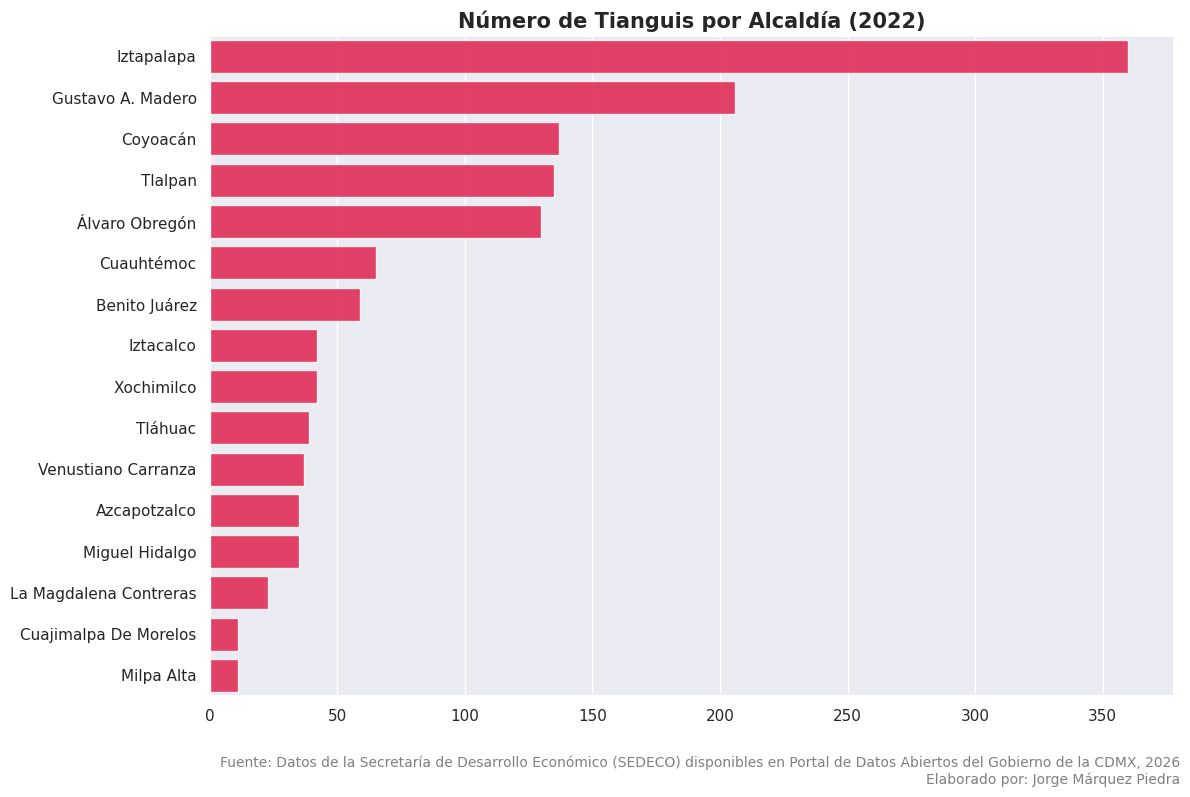

In [7]:
# Gráfica de conteo de tianguis por alcaldía
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.countplot(data = tianguis, y = 'alcaldia', order = tianguis['alcaldia'].value_counts().index, color = '#ff033f', alpha = 0.85)
plt.title('Número de Tianguis por Alcaldía (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('tianguis_por_alcaldia.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

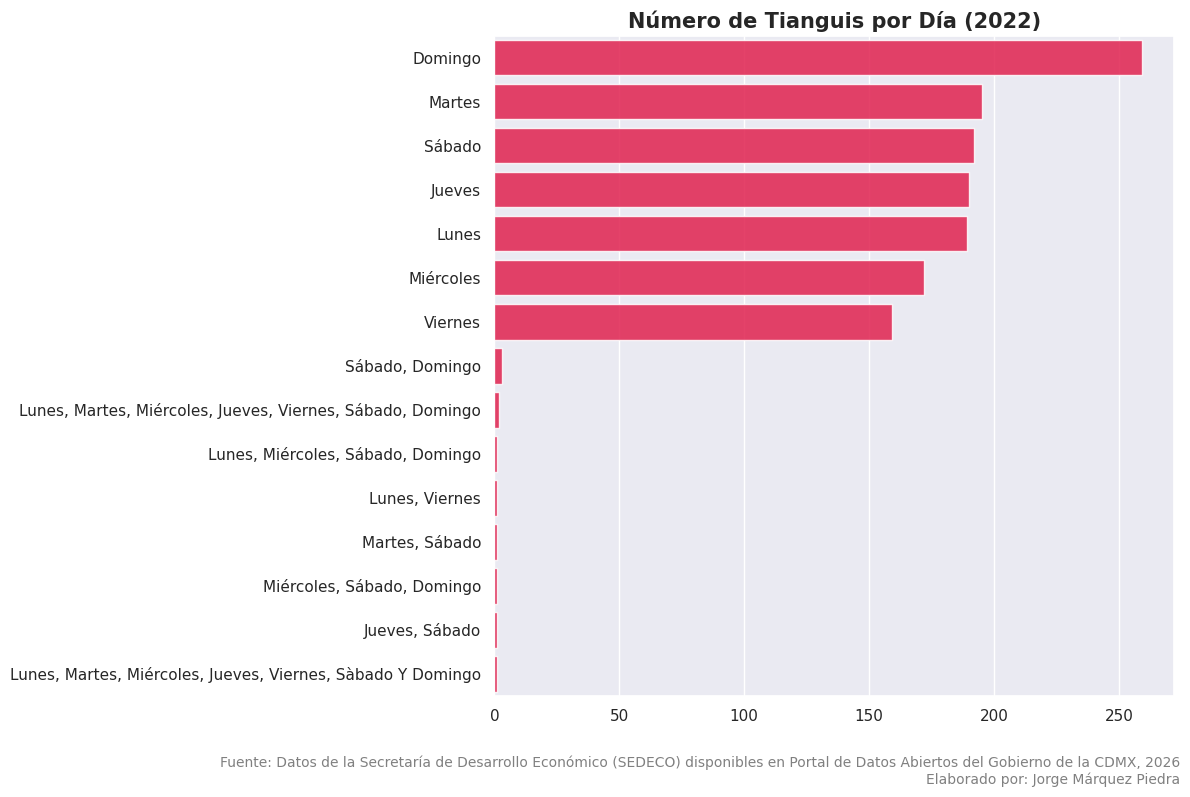

In [8]:
# Gráfica de conteo de tianguis por día de la semana
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.countplot(data = tianguis, y = 'dia', order = tianguis['dia'].value_counts().index, color = '#ff033f', alpha = 0.85)
plt.title('Número de Tianguis por Día (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('tianguis_por_dia.png', dpi = 300)
plt

In [9]:
# Revisar si hay valores nulos en la columna día
tianguis['dia'] = tianguis['dia'].fillna('No especificado').str.strip()

# Separar los días por la coma
tianguis['dia_limpio'] = tianguis['dia'].str.replace(' Y ', ', ', case=False)

# Convertimos el string en una lista: "Lunes, Martes" -> ["Lunes", "Martes"]
tianguis['dia_limpio'] = tianguis['dia_limpio'].str.split(', ')

# Función explode para expandir la lista en múltiples filas (una por cada día)
df_exp = tianguis.explode('dia_limpio').reset_index(drop=True)

# Limpieza final de espacios que pudieran quedar
df_exp['dia_limpio'] = df_exp['dia_limpio'].str.strip()

# Orden de días
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df_exp

,alcaldia,colonia,ubicacion,giro,dia,horario,latitud,longitud,dia_limpio
0,Álvaro Obregón,Piloto (Adolfo Lopez Mateos) (Ampl),Adolfo De La Huerta Entre Ruiz Cortinez Y Beni...,NaN,Lunes,8:00 A 17:00 Horas,19.375612,-99.221648,Lunes
1,Álvaro Obregón,Golondrinas 1Ra Seccion,Av. Chicago Entre Urano Y Jupiter,NaN,Lunes,8:00 A 17:00 Horas,19.381123,-99.209121,Lunes
2,Álvaro Obregón,Jose Maria Pino Suarez,Poniente 85 Y Av. Observatorio,NaN,Lunes,8:00 A 17:00 Horas,19.398888,-99.197936,Lunes
3,Álvaro Obregón,Tlacuitlapa,Calle Las Torres Y Antonio Machado,NaN,Lunes,8:00 A 17:00 Horas,19.355768,-99.240129,Lunes
4,Álvaro Obregón,Maria G De Garcia Ruiz,Av. Mexicanos Ent. Brasileã‘Os Y Uruguayos,NaN,Lunes,8:00 A 17:00 Horas,19.385972,-99.212968,Lunes
...,...,...,...,...,...,...,...,...,...
1391,Gustavo A. Madero,Unidad Habitacional Villa De Aragon,Villa Cacama Entre Av. Central Y Hank Gonzalez...,NaN,Domingo,07:00 A 17:00 Horas,19.463950,-99.056909,Domingo
1392,Milpa Alta,San Pablo Oztotepec,Calle Morelos Esquina Con Zapata Y Calle Rojo ...,ABASTO,Viernes,8:00 A 17:00 Horas,19.186960,-99.072973,Viernes
1393,Tlalpan,Col. Chimalcoyotl,Hermanos Pinzon Y Cristobal Colón,NaN,Miércoles,08:00 A 19:00 Horas,19.273726,-99.167265,Miércoles
1394,Coyoacán,Carmen Serdán,Boulevard Carmen Serdán Entre Magdalena Cobos ...,0,Miércoles,8:00 A 19:00 Horas,4.420572,-99.102604,Miércoles


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

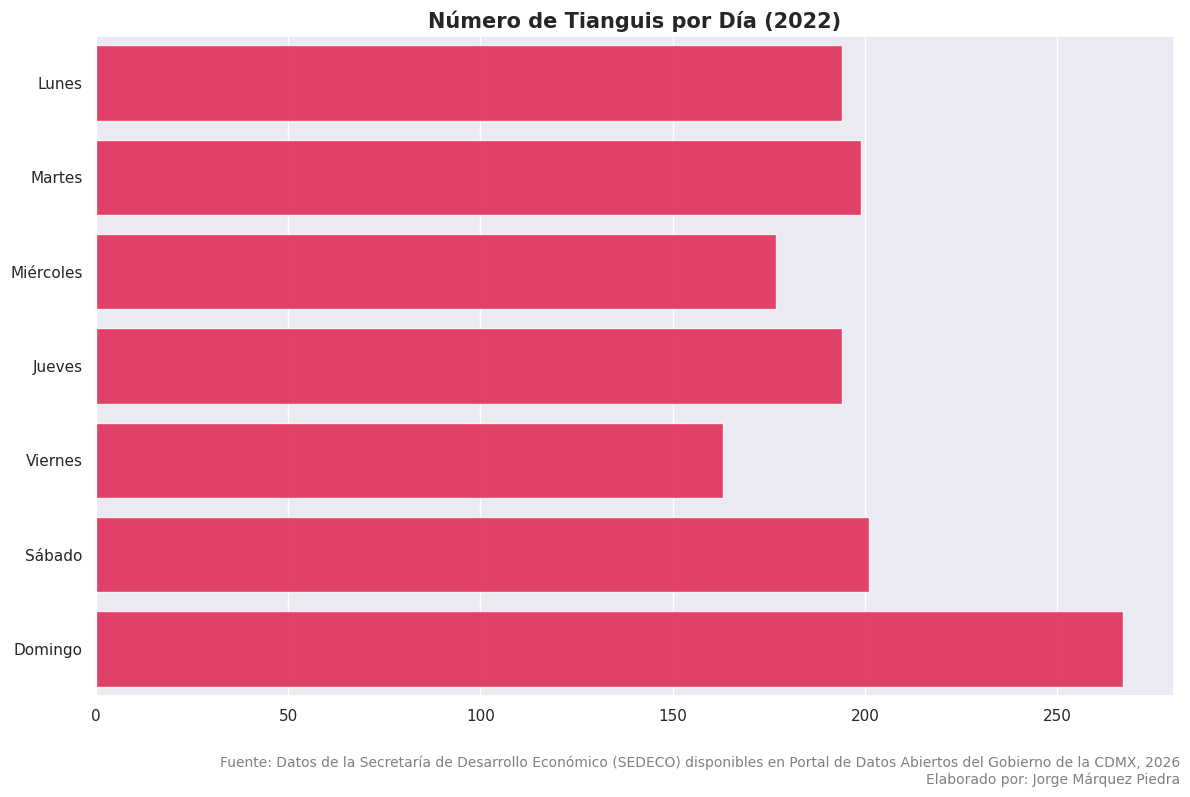

In [10]:
# Gráfica de conteo de tianguis por día de la semana
plt.figure(figsize = (12, 8))
sns.set_theme()
sns.countplot(data = df_exp, y = 'dia_limpio', order = orden_dias, color = '#ff033f', alpha = 0.85)
plt.title('Número de Tianguis por Día (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.xticks()
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('tianguis_por_dia.png', dpi = 300)
plt

In [11]:
# Transformar columan de horario en hora de inicio y hora de cierre

# Regex para buscar el formato HH:MM o H:MM
patron_hora = r'(\d{1,2}:\d{2})'

# Extraer todas las ocurrencias de horas en el string
horas_extraidas = tianguis['horario'].str.extractall(patron_hora).unstack()

# Crear columnas de inicio y fin (tomando la primera y la última hora hallada)
tianguis['hora_inicio'] = horas_extraidas[0][0] # Primera coincidencia
tianguis['hora_fin'] = horas_extraidas[0].iloc[:, -1] # Última coincidencia

# Convertir a formato datetime
tianguis['hora_inicio'] = pd.to_datetime(tianguis['hora_inicio'], format='%H:%M', errors='coerce').dt.hour
tianguis['hora_fin'] = pd.to_datetime(tianguis['hora_fin'], format='%H:%M', errors='coerce').dt.hour

tianguis

,alcaldia,colonia,ubicacion,giro,dia,horario,latitud,longitud,dia_limpio,hora_inicio,hora_fin
0,Álvaro Obregón,Piloto (Adolfo Lopez Mateos) (Ampl),Adolfo De La Huerta Entre Ruiz Cortinez Y Beni...,NaN,Lunes,8:00 A 17:00 Horas,19.375612,-99.221648,[Lunes],8,17
1,Álvaro Obregón,Golondrinas 1Ra Seccion,Av. Chicago Entre Urano Y Jupiter,NaN,Lunes,8:00 A 17:00 Horas,19.381123,-99.209121,[Lunes],8,17
2,Álvaro Obregón,Jose Maria Pino Suarez,Poniente 85 Y Av. Observatorio,NaN,Lunes,8:00 A 17:00 Horas,19.398888,-99.197936,[Lunes],8,17
3,Álvaro Obregón,Tlacuitlapa,Calle Las Torres Y Antonio Machado,NaN,Lunes,8:00 A 17:00 Horas,19.355768,-99.240129,[Lunes],8,17
4,Álvaro Obregón,Maria G De Garcia Ruiz,Av. Mexicanos Ent. Brasileã‘Os Y Uruguayos,NaN,Lunes,8:00 A 17:00 Horas,19.385972,-99.212968,[Lunes],8,17
...,...,...,...,...,...,...,...,...,...,...,...
1362,Gustavo A. Madero,Unidad Habitacional Villa De Aragon,Villa Cacama Entre Av. Central Y Hank Gonzalez...,NaN,Domingo,07:00 A 17:00 Horas,19.463950,-99.056909,[Domingo],7,17
1363,Milpa Alta,San Pablo Oztotepec,Calle Morelos Esquina Con Zapata Y Calle Rojo ...,ABASTO,Viernes,8:00 A 17:00 Horas,19.186960,-99.072973,[Viernes],8,17
1364,Tlalpan,Col. Chimalcoyotl,Hermanos Pinzon Y Cristobal Colón,NaN,Miércoles,08:00 A 19:00 Horas,19.273726,-99.167265,[Miércoles],8,19
1365,Coyoacán,Carmen Serdán,Boulevard Carmen Serdán Entre Magdalena Cobos ...,0,Miércoles,8:00 A 19:00 Horas,4.420572,-99.102604,[Miércoles],8,19


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

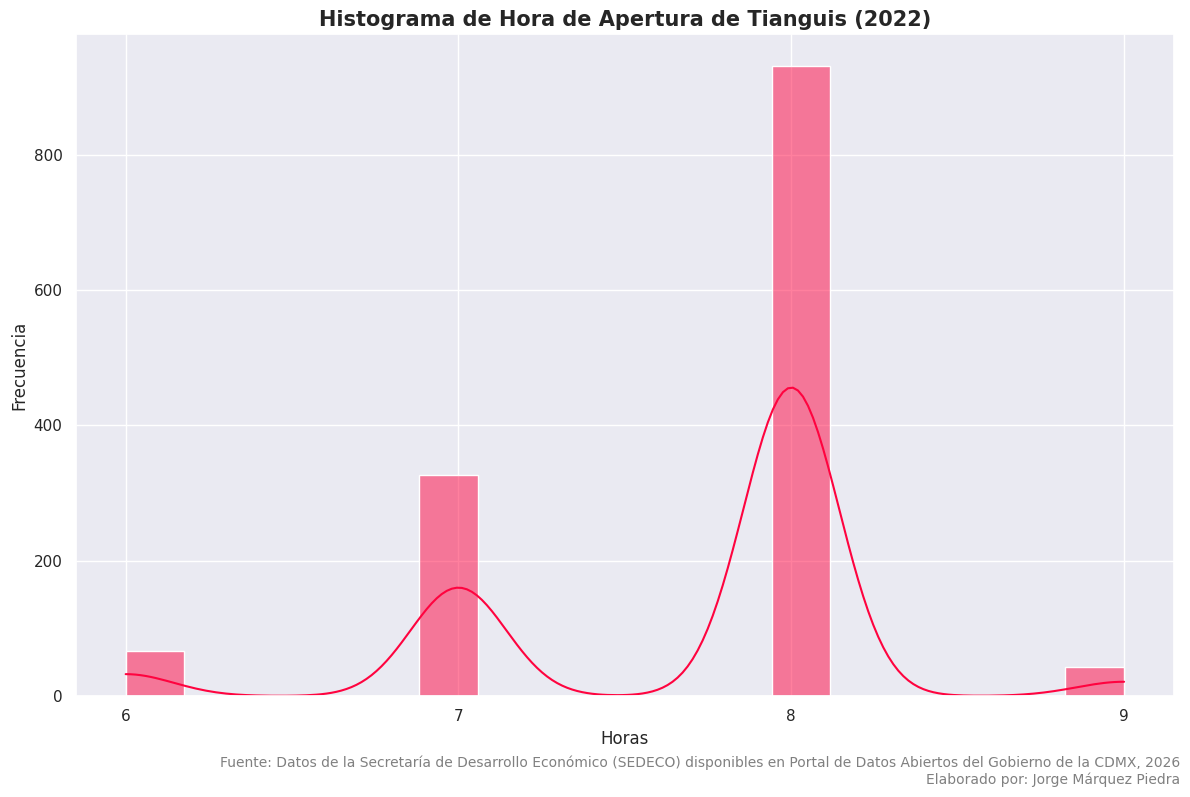

In [12]:
# Histograma de hora de apertura
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = tianguis, x = 'hora_inicio', kde = True, color = '#ff033f')
plt.title('Histograma de Hora de Apertura de Tianguis (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Horas')
plt.ylabel('Frecuencia')
plt.xticks([6, 7, 8, 9])
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('histograma_hora_de_apertura.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

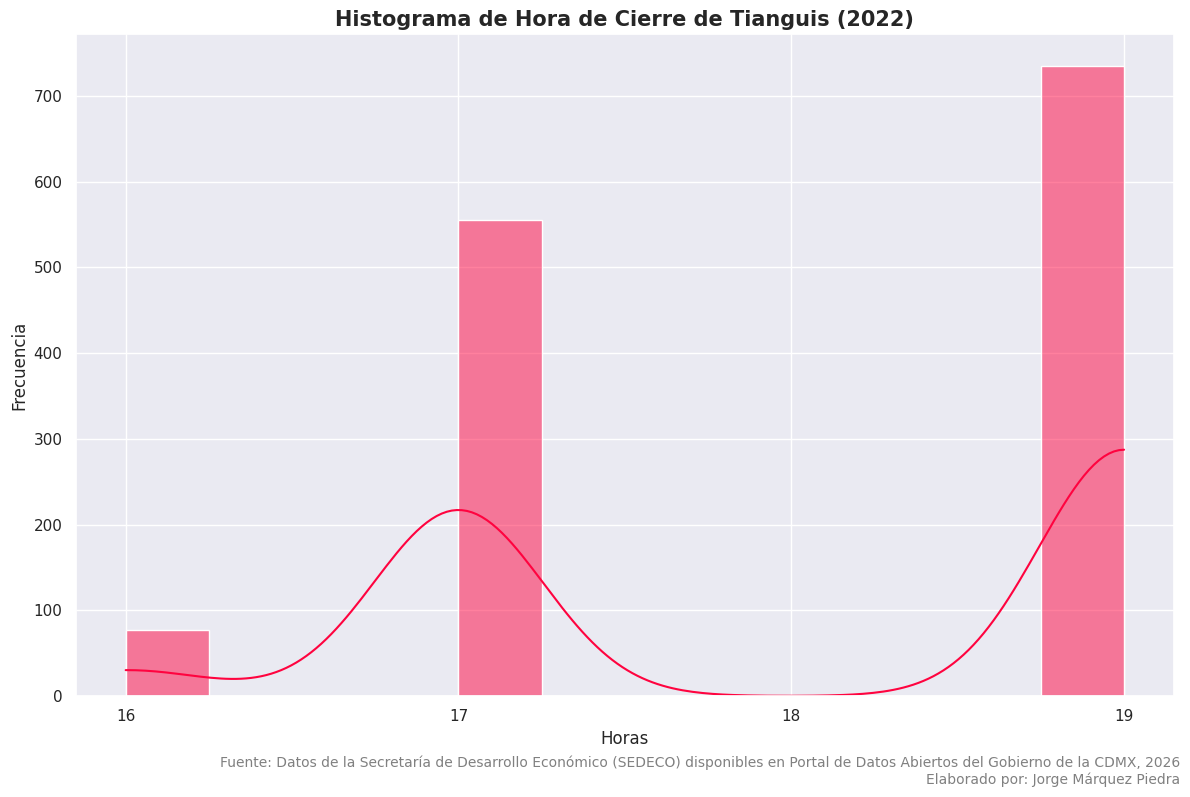

In [13]:
# Histograma de hora de apertura
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.histplot(data = tianguis, x = 'hora_fin', kde = True, color = '#ff033f')
plt.title('Histograma de Hora de Cierre de Tianguis (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Horas')
plt.ylabel('Frecuencia')
plt.xticks([16, 17, 18, 19])
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('histograma_hora_de_cierre.png', dpi = 300)
plt

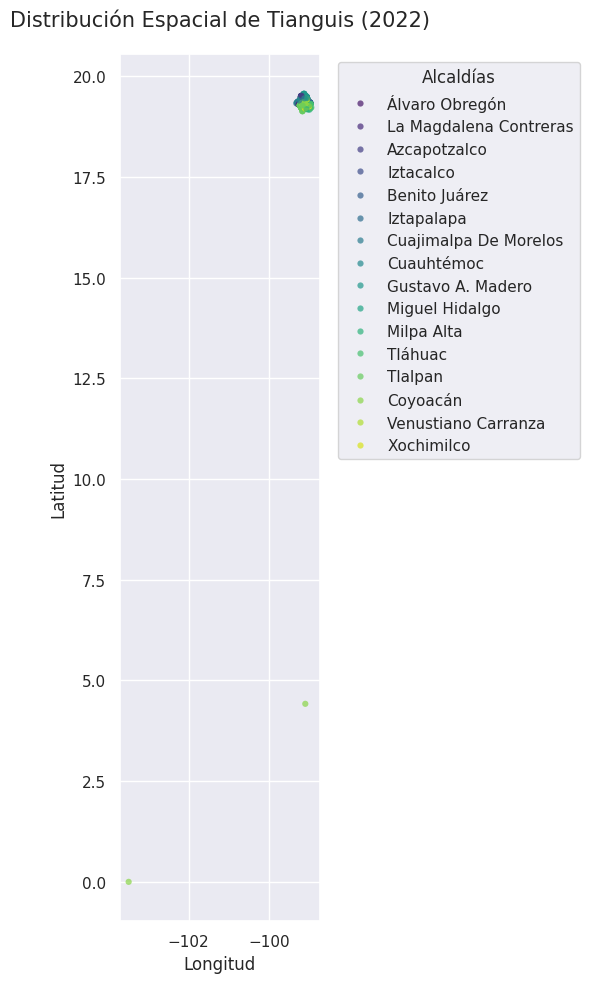

In [14]:
# Mapa (scatterplot) de tianguis
plt.figure(figsize=(10, 10))
sns.set_theme()
sns.scatterplot(
    data=tianguis,
    x='longitud',
    y='latitud',
    hue='alcaldia',
    palette='viridis',
    s=20,
    alpha=0.7,
    edgecolor='none'
)
plt.title('Distribución Espacial de Tianguis (2022)', fontsize=15, pad=20)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Alcaldías')
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

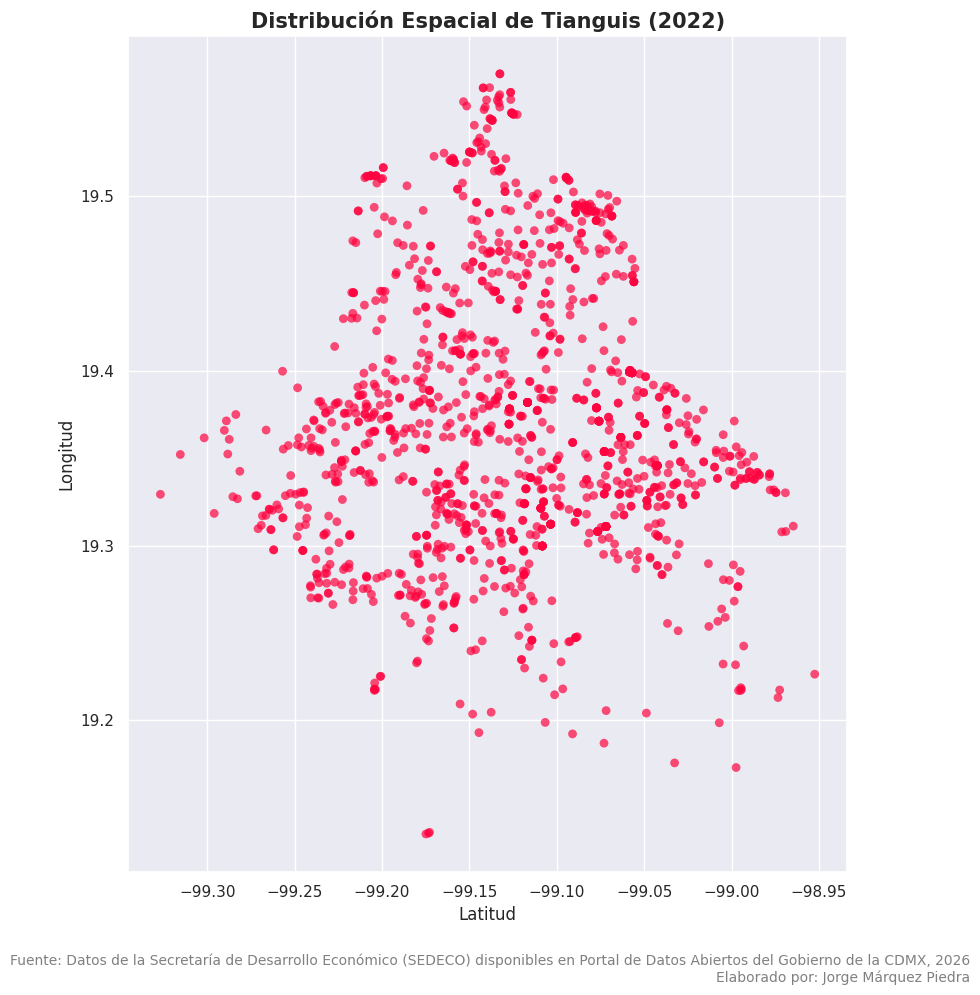

In [44]:
# Fitro usando coordenadas de la CDMX
# Eliminar puntos en 0 o latitudes erróneas
tianguis_clean = tianguis[
    (tianguis['latitud'] > 19.0) & (tianguis['latitud'] < 19.6) &
    (tianguis['longitud'] > -99.4) & (tianguis['longitud'] < -98.9)
].copy()

# Crear mapa corregido
plt.figure(figsize=(10, 10))
sns.set_theme()
sns.scatterplot(
    data = tianguis_clean,
    x = 'longitud',
    y = 'latitud',
    color = '#ff033f',
    s = 40, # Tamaño de los puntos
    alpha = 0.7,
    edgecolor = 'none'
)
plt.title('Distribución Espacial de Tianguis (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Latitud')
plt.ylabel('Longitud')
plt.gca().set_aspect('equal', adjustable = 'box')
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('mapa_tianguis.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

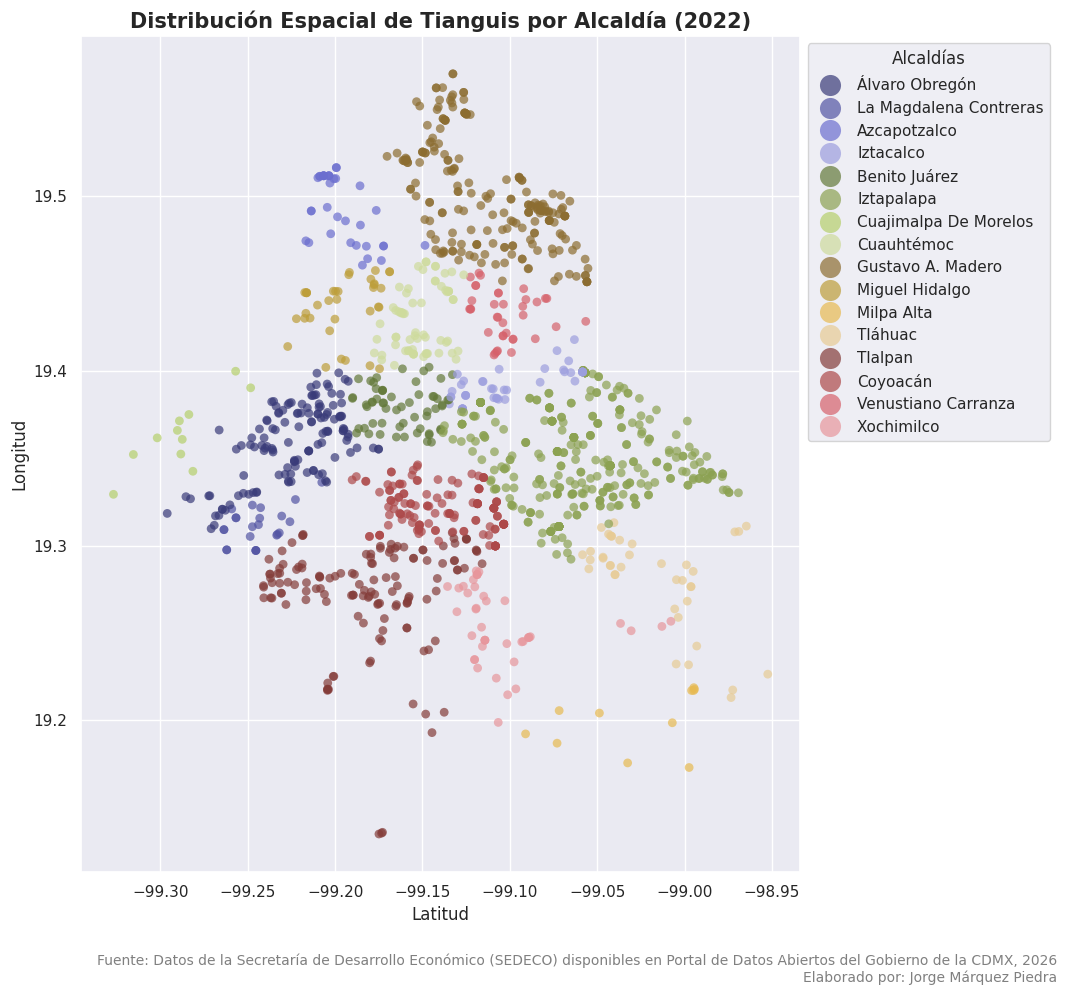

In [59]:
# Fitro usando coordenadas de la CDMX
# Eliminar puntos en 0 o latitudes erróneas
tianguis_clean = tianguis[
    (tianguis['latitud'] > 19.0) & (tianguis['latitud'] < 19.6) &
    (tianguis['longitud'] > -99.4) & (tianguis['longitud'] < -98.9)
].copy()

# Crear mapa corregido
plt.figure(figsize=(11, 10))
sns.set_theme()
sns.scatterplot(
    data = tianguis_clean,
    x = 'longitud',
    y = 'latitud',
    hue = 'alcaldia',
    palette = 'tab20b',
    s = 40, # Tamaño de los puntos
    alpha = 0.7,
    edgecolor = 'none'
)
plt.title('Distribución Espacial de Tianguis por Alcaldía (2022)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Latitud')
plt.ylabel('Longitud')
plt.legend(bbox_to_anchor = (1.0, 1), loc = 'upper left', title = 'Alcaldías', markerscale = 2.4)
plt.gca().set_aspect('equal', adjustable = 'box')
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('mapa_tianguis_alcaldia.png', dpi = 300)
plt

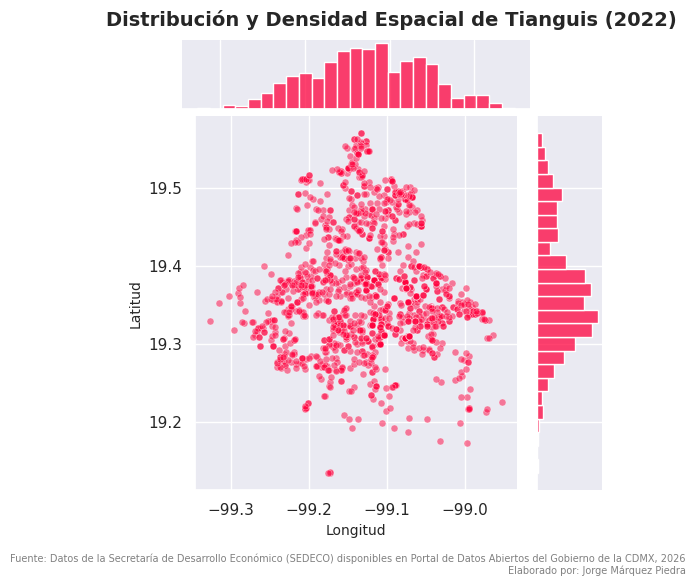

In [16]:
# Distribución y densidad
sns.set_theme()
g = sns.jointplot(
    data = tianguis_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'scatter',
    color = '#ff033f',
    alpha = 0.5,
    s = 25,
    marginal_kws = dict(bins=25, fill=True), # Mejorar la visibilidad de los histogramas
    ratio = 5,   # Mapa 5 veces más grande que los histogramas
    space = 0.1  # Espacio pequeño entre el mapa y las barras
)
g.ax_joint.set_aspect('equal')
g.fig.suptitle('Distribución y Densidad Espacial de Tianguis (2022)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.95)
g.set_axis_labels('Longitud', 'Latitud', fontsize=10)

# Corrección de Proporción (Aspect Ratio), esto evita que la ciudad se vea "estirada" o "aplastada"
g.ax_joint.set_aspect('equal')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment='right', fontsize=7, color='gray')

# Ajuste de márgenes
plt.subplots_adjust(left = 0.15, right = 0.85, top = 0.9, bottom = 0.15)

plt.savefig('mapa_tianguis_joint_scatter.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


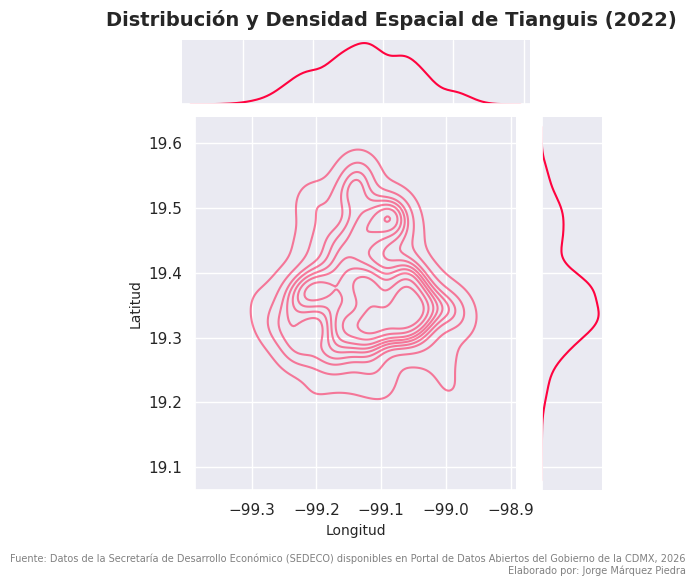

In [17]:
# Distribución y densidad
sns.set_theme()
g = sns.jointplot(
    data = tianguis_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'kde',
    color = '#ff033f',
    alpha = 0.5,
    s = 25
)
g.fig.suptitle('Distribución y Densidad Espacial de Tianguis (2022)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.95)
g.set_axis_labels('Longitud', 'Latitud', fontsize = 10)

# Corrección de Proporción (Aspect Ratio), esto evita que la ciudad se vea "estirada" o "aplastada"
g.ax_joint.set_aspect('equal')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 7, color = 'gray')

# Ajuste de márgenes
plt.subplots_adjust(left = 0.15, right = 0.85, top = 0.9, bottom = 0.15)

plt.savefig('mapa_tianguis_joint_kde.png', dpi = 300, bbox_inches = 'tight')
plt.show()

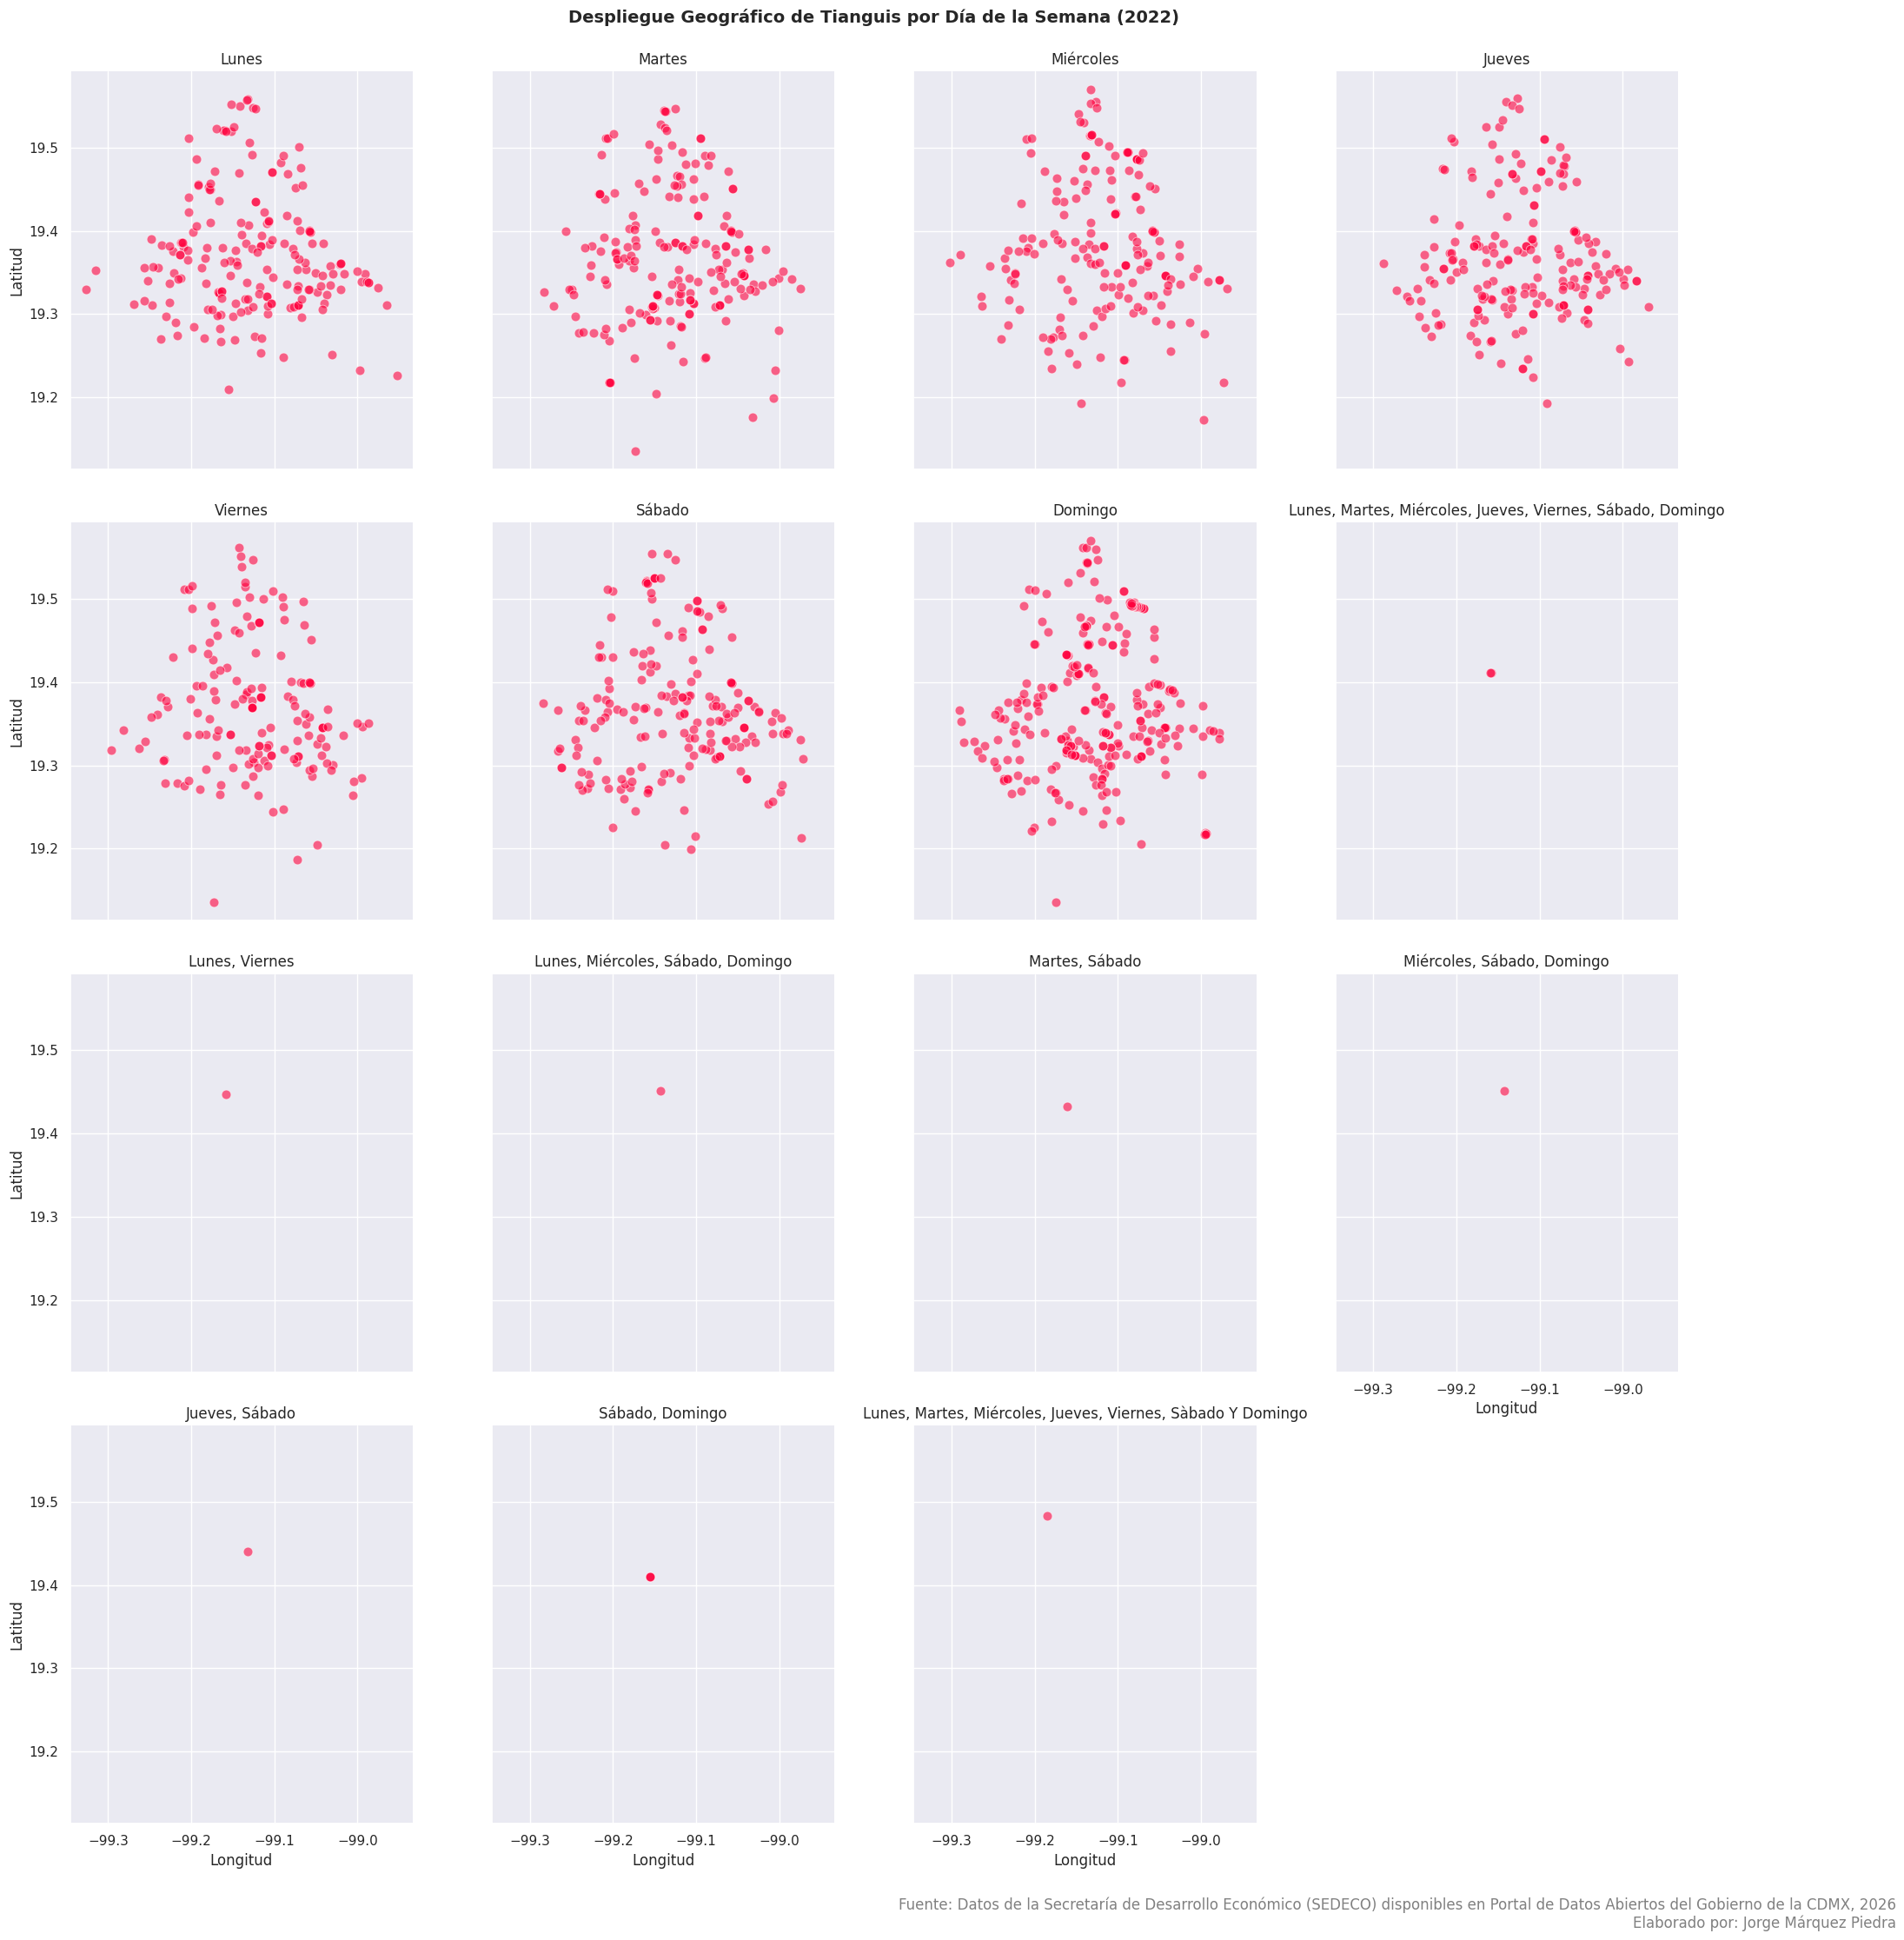

In [57]:
# Mapas por días de la semana
g = sns.FacetGrid(tianguis_clean, col = "dia", col_wrap = 4, height = 6)
g.map_dataframe(
    sns.scatterplot,
    x = "longitud",
    y = "latitud",
    s = 60,
    alpha = 0.6,
    color = '#ff033f'
)

g.set_titles("{col_name}")
g.set_axis_labels("Longitud", "Latitud")

plt.subplots_adjust(top = 1.5)
g.fig.suptitle('Despliegue Geográfico de Tianguis por Día de la Semana (2022)',
               fontsize = 14,
               fontweight = 'bold',
               y = 0.93)

# Aplicar aspect equal a todos los plots
for ax in g.axes.flat:
    ax.set_aspect('equal', adjustable = 'box')

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 12, color = 'gray')
plt.subplots_adjust(left = 0.1, right = 0.9, top = 0.9, bottom = 0.06)
plt.savefig('mapa_tianguis_por_dias.png', dpi = 300, bbox_inches = 'tight')
plt.show()

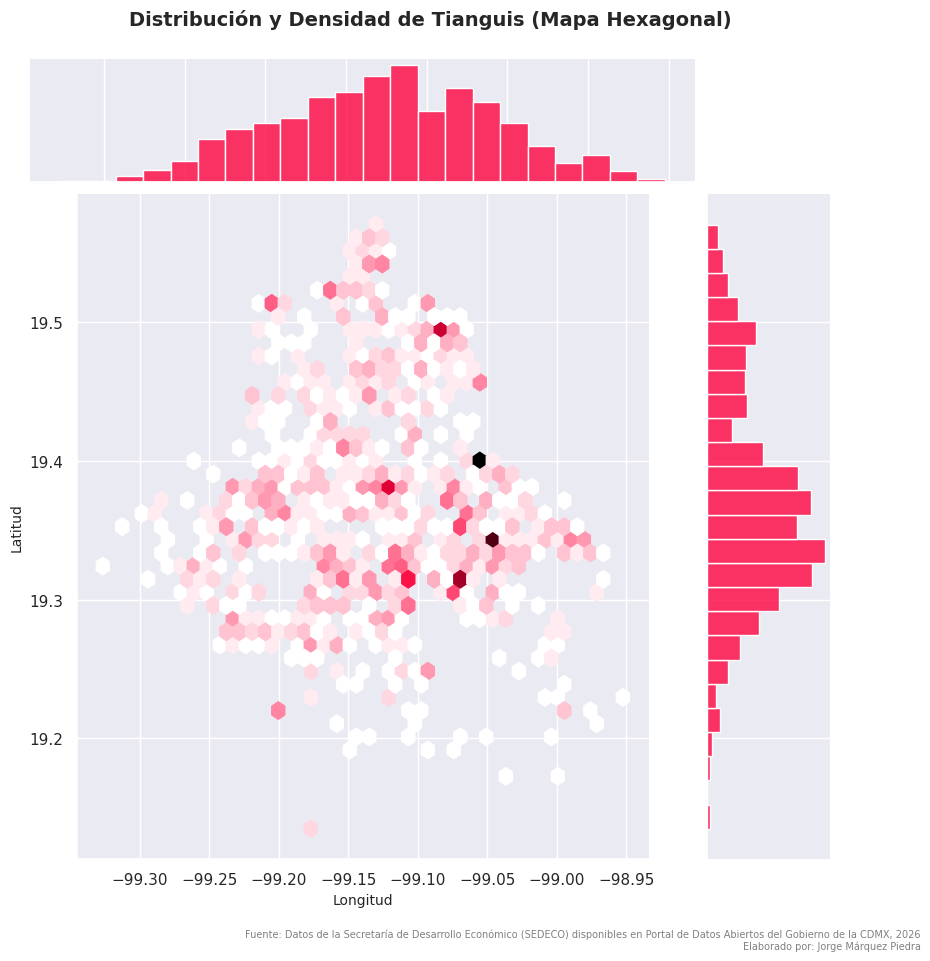

In [49]:
# Mapa Hexbins
sns.set_theme()
g = sns.jointplot(
    data = tianguis_clean,
    x = 'longitud',
    y = 'latitud',
    kind = 'hex',
    color = '#ff033f',
    gridsize = 40,#35,       # Tamaño de los hexágonos (mayor número = más pequeños)
    mincnt = 1,          # No dibujar hexágonos donde no hay datos
    ratio = 5,
    space = 0.1,
    height = 10,
    marginal_kws = dict(color = '#ff033f', fill = True, alpha = 0.8)
)

g.ax_joint.set_aspect('equal')

g.fig.suptitle('Distribución y Densidad de Tianguis (Mapa Hexagonal)',
               fontsize = 14, fontweight = 'bold', y = 0.95)

g.set_axis_labels('Longitud', 'Latitud', fontsize = 10)

g.fig.text(0.99, 0.01,
           'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra',
           horizontalalignment = 'right', fontsize = 7, color = 'gray')

plt.subplots_adjust(left = 0.1, right = 0.9, top = 0.9, bottom = 0.1)

plt.savefig('mapa_tianguis_hexagonal.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [27]:
# Calcular la duración en horas
tianguis_clean['duracion'] = tianguis_clean['hora_fin'] - tianguis_clean['hora_inicio']

# Corrección para horarios que cruzan la medianoche (si existieran)
tianguis_clean.loc[tianguis_clean['duracion'] < 0, 'duracion'] += 24

# Filtrar valores (por ejemplo, jornadas de entre 1 y 12 horas)
df_duracion = tianguis_clean[(tianguis_clean['duracion'] > 0) & (tianguis_clean['duracion'] < 12)]

/tmp/ipykernel_178/656040905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

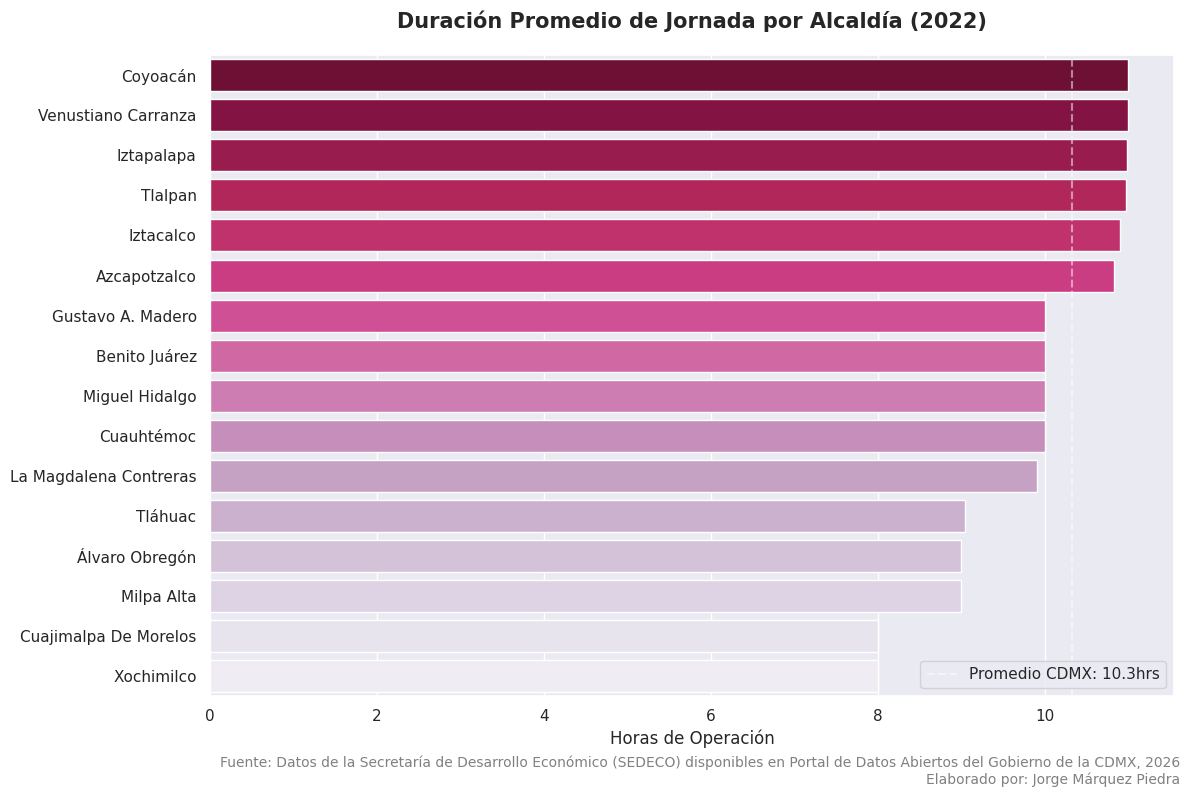

In [39]:
sns.set_theme()
plt.figure(figsize=(12, 8))

orden_alcaldias = df_duracion.groupby('alcaldia')['duracion'].mean().sort_values(ascending=False).index

sns.barplot(
    data = df_duracion,
    x = 'duracion',
    y = 'alcaldia',
    order = orden_alcaldias,
    palette = 'PuRd_r',
    errorbar = None    # Quitar las barras de error
)

# Añadir línea vertical con el promedio general
promedio_global = df_duracion['duracion'].mean()
plt.axvline(promedio_global, color = 'white', linestyle = '--', alpha = 0.5, label = f'Promedio CDMX: {promedio_global:.1f}hrs')
plt.title('Duración Promedio de Jornada por Alcaldía (2022)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Horas de Operación')
plt.ylabel(None)
plt.legend(loc = 'lower right')
plt.figtext(0.99, 0.01, 'Fuente: Datos de la Secretaría de Desarrollo Económico (SEDECO) disponibles en Portal de Datos Abiertos del Gobierno de la CDMX, 2026\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('duracion_jornada_tianguis.png', dpi = 300)
plt